# Bonus - SIR Model of Epidemics Control

In [1]:
%run "Ch00 - Basic Imports and Set ups.ipynb"

Found in: .\Ch00 - Basic Imports and Set ups.ipynb (Cell #4)
Found in: .\Ch06 - Data Loading, Storage, and File Formats.ipynb (Cell #208)
Found in: .\Ch06 - Data Loading, Storage, and File Formats.ipynb (Cell #219)
Found in: .\Ch06 - Data Loading, Storage, and File Formats.ipynb (Cell #220)
Found in: .\forgitandbinder\PyData-Analysis-3E-Wes-McKinney\Ch00 - Basic Imports and Set ups.ipynb (Cell #4)
Found in: .\forgitandbinder\PyData-Analysis-3E-Wes-McKinney\Ch06 - Data Loading, Storage, and File Formats.ipynb (Cell #208)
Found in: .\forgitandbinder\PyData-Analysis-3E-Wes-McKinney\Ch06 - Data Loading, Storage, and File Formats.ipynb (Cell #219)
Found in: .\forgitandbinder\PyData-Analysis-3E-Wes-McKinney\Ch06 - Data Loading, Storage, and File Formats.ipynb (Cell #220)


In [2]:
jupyter nbextension enable --py widgetsnbextension

SyntaxError: invalid syntax (2269694994.py, line 1)

---

---

# 📘 SIR Model — History, Scenario, Concepts and Simulation

---

## ✅ Brief History of the SIR Model

The **SIR model** was introduced in **1927** by:

* **William O. Kermack**
* **Anderson G. McKendrick**

They wanted to understand:

> Why epidemics rise, peak, and then decline — even without complete immunity or interventions.

Before this work, epidemic spread was studied mainly using statistics.
They introduced a **dynamic mathematical model using differential equations**, which became the foundation of **modern epidemiological modelling**.

Today SIR-type models are used in:

* pandemic prediction
* vaccination policy design
* hospital capacity planning
* information / rumor spread modelling
* computer virus propagation

---

## ✅ Real-World Scenario Behind the Model

Imagine a closed town of **1000 people**.

At the beginning:

* 1 person is infected
* 999 people are healthy but can get infected

As time passes:

* infected people meet healthy people → disease spreads
* infected people recover → become immune

Eventually:

* fewer susceptible people remain
* epidemic naturally slows and stops

The SIR model mathematically describes this process.

---

## ✅ Population Compartments

At any time ( t ):

* **S(t)** → Susceptible
* **I(t)** → Infected
* **R(t)** → Recovered (or Removed)

Total population:
$$
[
N = S + I + R
]
$$
Population is assumed **constant (closed system)**.

---

## ✅ Important Rates

### ⭐ Transmission Rate ( β )

Measures how quickly infection spreads.

Depends on:

* number of contacts per day
* probability infection happens per contact

---

### ⭐ Recovery Rate ( γ )

Measures how quickly infected people stop spreading disease.

If infectious duration = D days:

$$
[
\gamma = 1/D
]
$$

---

## ✅ Infection Interaction Term

New infections depend on both:

* susceptible people
* infected people

Thus:
$$
[
\beta \frac{SI}{N}
]
$$
This assumes **random mixing of population**.

---

## ✅ SIR Differential Equations

### Susceptible

$$
[
\frac{dS}{dt} = -\beta \frac{SI}{N}
]
$$
### Infected

$$
[
\frac{dI}{dt} = \beta \frac{SI}{N} - \gamma I
]
$$

### Recovered
$$
[
\frac{dR}{dt} = \gamma I
]
$$
These equations describe **flow of people between compartments**.

---

## ✅ Basic Reproduction Number
$$
[
R_0 = \frac{\beta}{\gamma}
]
$$
* ( R_0 > 1 ) → epidemic grows
* ( R_0 < 1 ) → epidemic dies

---

## ✅ Numerical Simulation Idea

Analytical solutions are difficult.

So we simulate using **Euler time stepping**:
$$
[
X_{t+1} = X_t + dt \cdot \frac{dX}{dt}
]
$$
We update S, I, R repeatedly over time.

---



# Simulation

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider

def sir_simulation(N=1000, beta=0.3, gamma=0.1, I0=1, T=160):

    dt = 0.1
    steps = int(T / dt)

    S = np.zeros(steps)
    I = np.zeros(steps)
    R = np.zeros(steps)

    S[0] = N - I0
    I[0] = I0
    R[0] = 0

    time = np.linspace(0, T, steps)

    for t in range(steps - 1):

        infection = beta * S[t] * I[t] / N
        recovery = gamma * I[t]

        S[t+1] = S[t] - dt * infection
        I[t+1] = I[t] + dt * (infection - recovery)
        R[t+1] = R[t] + dt * recovery

    plt.figure(figsize=(10,6))
    plt.plot(time, S, label="Susceptible")
    plt.plot(time, I, label="Infected")
    plt.plot(time, R, label="Recovered")

    R0 = beta / gamma

    plt.title(f"SIR Simulation  (R₀ = {R0:.2f})")
    plt.xlabel("Days")
    plt.ylabel("Population")
    plt.legend()
    plt.grid()
    plt.show()


interact(
    sir_simulation,
    N=IntSlider(min=200, max=5000, step=100, value=1000),
    beta=FloatSlider(min=0.05, max=1.0, step=0.05, value=0.3),
    gamma=FloatSlider(min=0.05, max=0.5, step=0.05, value=0.1),
    I0=IntSlider(min=1, max=50, step=1, value=1),
    T=IntSlider(min=50, max=300, step=10, value=160)
);

interactive(children=(IntSlider(value=1000, description='N', max=5000, min=200, step=100), FloatSlider(value=0…

## ✅ Brief Summary — Epidemic Scenario Planning with SIR + Hospital Capacity

This simulation is used to **plan healthcare capacity during an epidemic** by combining:

* **Disease spread dynamics (SIR model)**
* **Hospital resource constraints (bed availability)**

---

## ⭐ Purpose of the Scenario Planning

The goal is to answer a practical question:

> **Will available hospital beds be sufficient during the epidemic peak?**

Instead of only studying infection curves, we connect them to **real operational limits** like hospital capacity.

---

## ⭐ Epidemic Model Assumptions

The population is divided into:

* **Susceptible (S)** → people who can get infected
* **Infected (I)** → people currently spreading disease
* **Recovered (R)** → immune / removed

Disease spread depends on:

* **Transmission rate (β)** → how fast infection spreads
* **Recovery rate (γ)** → how fast infected people recover

Using these, we simulate how infections evolve over time.

---

## ⭐ Hospital Demand Modelling

Not all infected people need hospitalization.

So we assume:

> **Hospital Demand = hospitalization rate × infected population**

This gives a time-varying curve representing **stress on healthcare infrastructure.**

---

## ⭐ Capacity Scenarios Compared

Two planning scenarios are evaluated:

### ✅ Scenario 1 — Constant Capacity

Hospital beds remain fixed (e.g., **180 beds throughout**).

This helps check:

* Is existing infrastructure sufficient?

---

### ✅ Scenario 2 — Delayed Capacity Expansion

* Fewer beds initially (e.g., **120 beds**)
* Capacity increases later (e.g., after **6 days to 180 beds**)

This tests:

* Whether **timing of resource scaling** is early enough to handle peak demand.

---

## ⭐ Key Planning Insights from Simulation

This analysis helps decision-makers understand:

* When infection peak occurs
* Whether hospital demand exceeds capacity
* How long the system remains overwhelmed
* Whether expanding capacity earlier would help
* How reducing transmission (lockdowns, masks, vaccination) can prevent collapse

---

## ⭐ Why This is Important

Such models are used in real life for:

* Pandemic preparedness
* Lockdown timing decisions
* Vaccine rollout planning
* ICU / bed allocation strategy
* Emergency resource mobilization

In short:

> **It converts epidemic spread into actionable operational planning.**

---



In [3]:
import numpy as np
import plotly.graph_objects as go
from ipywidgets import interact, FloatSlider, IntSlider

def hospital_sir(
    N=1000,
    beta=0.1,
    gamma=0.05,
    I0=10,
    hosp_rate=0.15,
    beds_full=180,
    beds_initial=120,
    switch_day=6,
    Days=120
):

    dt = 0.1
    steps = int(Days/dt)

    S = np.zeros(steps)
    I = np.zeros(steps)
    R = np.zeros(steps)

    time = np.linspace(0, Days, steps)

    S[0] = N - I0
    I[0] = I0

    for t in range(steps-1):

        infection = beta * S[t] * I[t] / N
        recovery = gamma * I[t]

        S[t+1] = S[t] - dt * infection
        I[t+1] = I[t] + dt * (infection - recovery)
        R[t+1] = R[t] + dt * recovery

    hospital_demand = hosp_rate * I

    beds_s1 = np.full(steps, beds_full)
    beds_s2 = np.where(time <= switch_day, beds_initial, beds_full)

    peak = hospital_demand.max()
    peak_day = time[np.argmax(hospital_demand)]

    fig = go.Figure()

    # ---- SIR curves ----
    fig.add_trace(go.Scatter(x=time, y=S, name="Susceptible"))
    fig.add_trace(go.Scatter(x=time, y=I, name="Infected", line=dict(width=4)))
    fig.add_trace(go.Scatter(x=time, y=R, name="Recovered"))

    # ---- Hospital demand ----
    fig.add_trace(go.Scatter(
        x=time,
        y=hospital_demand,
        name="Hospital Demand",
        line=dict(width=4, dash="dot")
    ))

    # ---- Capacity ----
    fig.add_trace(go.Scatter(
        x=time,
        y=beds_s1,
        name="Beds Scenario 1",
        line=dict(dash="dash")
    ))

    fig.add_trace(go.Scatter(
        x=time,
        y=beds_s2,
        name="Beds Scenario 2",
        line=dict(dash="longdash")
    ))

    fig.add_vline(x=switch_day)

    fig.update_layout(
        title=f"Peak Hospital Demand = {peak:.1f} at Day {peak_day:.1f}",
        xaxis_title="Days",
        yaxis_title="People",
        height=650
    )

    fig.show()


interact(
    hospital_sir,
    N=IntSlider(value=1000, min=500, max=5000, step=100),
    beta=FloatSlider(value=0.1, min=0.05, max=0.5, step=0.01),
    gamma=FloatSlider(value=0.05, min=0.02, max=0.2, step=0.01),
    I0=IntSlider(value=10, min=1, max=50),
    hosp_rate=FloatSlider(value=0.15, min=0.05, max=1, step=0.01),
    beds_full=IntSlider(value=180, min=50, max=400),
    beds_initial=IntSlider(value=120, min=50, max=300),
    switch_day=IntSlider(value=6, min=1, max=200),   # same possible range as Days
    Days=IntSlider(value=120, min=60, max=200)
);

interactive(children=(IntSlider(value=1000, description='N', max=5000, min=500, step=100), FloatSlider(value=0…

##### SIR Probabilistic Simulation — Parameter Sweep (Monte-Carlo Epidemiological Scenario Study)

In the earlier step we built a **deterministic SIR simulator**, where we fixed values of infection rate (β) and recovery rate (γ).

However, in real life:

* Infection rate is **not known exactly**
* Recovery rate is **not constant across populations**
* Policy makers must plan for **uncertainty**

So instead of saying:

> “β = 0.1 and γ = 0.05”

We now say:

> “β can vary between 0.05 and 0.15
> γ can vary between 0 and 0.1 with most likely value near 0.05”

This is called:

### **Monte-Carlo Parameter Uncertainty Simulation**

What we are doing:

1. Generate **100 possible values of β** from a Uniform distribution
2. Generate **100 possible values of γ** from a Triangular distribution
3. Run **SIR simulation for every combination → 10,000 epidemic scenarios**
4. For each scenario we compute:

   * Maximum number of infected people (peak load on healthcare)
   * Day when infection peaks (timing risk)
5. Store all results in a **structured dataset (DataFrame)**
   → This allows risk analysis, probability estimation, planning etc.

We are **NOT plotting yet** — only building the simulation engine and dataset.

---


##### What You Have Built (Very Important Data Science View)

You now have:

> **A synthetic epidemic risk dataset generated via simulation**

This is extremely powerful because now you can:

* Estimate **probability of severe outbreak**
* Compute **expected peak hospital demand**
* Understand **sensitivity of outbreak to β vs γ**
* Identify **worst case planning scenarios**
* Build **policy decision support models**



In [5]:
import numpy as np
import pandas as pd


# ---------- SIR Solver Function ----------

def run_sir_once(beta, gamma, N=1000, I0=1, T=160, dt=0.1):

    steps = int(T / dt)

    S = np.zeros(steps)
    I = np.zeros(steps)
    R = np.zeros(steps)

    S[0] = N - I0
    I[0] = I0
    R[0] = 0

    for t in range(steps - 1):

        infection = beta * S[t] * I[t] / N
        recovery = gamma * I[t]

        S[t+1] = S[t] - dt * infection
        I[t+1] = I[t] + dt * (infection - recovery)
        R[t+1] = R[t] + dt * recovery

    peak_infections = np.max(I)
    peak_index = np.argmax(I)
    peak_day = peak_index * dt

    return peak_infections, peak_day


# ---------- Generate Probabilistic Parameters ----------

np.random.seed(42)

beta_samples = np.random.uniform(
    low=0.05,
    high=0.15,
    size=100
)

gamma_samples = np.random.triangular(
    left=0.0,
    mode=0.05,
    right=0.1,
    size=100
)


# ---------- Run Full Monte-Carlo Combination Simulation ----------

results = []

for beta in beta_samples:
    for gamma in gamma_samples:

        peak_I, peak_day = run_sir_once(beta, gamma)

        results.append({
            "beta": beta,
            "gamma": gamma,
            "R0": beta / gamma if gamma > 0 else np.nan,
            "peak_infections": peak_I,
            "peak_day": peak_day
        })


# ---------- Convert to Dataset ----------

df_results = pd.DataFrame(results)

print(df_results.shape)   # Should be (10000, 5)
df_results.head()

(10000, 5)


,beta,gamma,R0,peak_infections,peak_day
0,0.087454,0.012536,6.976349,578.869211,118.8
1,0.087454,0.057363,1.524582,56.766166,159.9
2,0.087454,0.039646,2.205890,188.681145,147.0
3,0.087454,0.050430,1.734153,103.730706,159.9
4,0.087454,0.078502,1.114037,3.516821,159.9


##### Histogram of Peak Infections with Likelihood (Probability Density)

Now we move from **simulation → statistical interpretation.**

We already generated **10,000 epidemic scenarios** and stored:

```
df_results["peak_infections"]
```

Now the goal is:

> Build a histogram that shows **how likely different peak infection ranges are**

This is extremely important in real decision science because:

* Government does NOT care about one simulation
* They care about **probability distribution of outcomes**

Example thinking:

* Peak infections 200–250 → probability 8%
* Peak infections 300–350 → probability 20%
* Peak infections 500+ → probability 2%

This is called:

### **Empirical Likelihood Distribution**

We estimate likelihood using:

```
count_in_bin / total_simulations
```

---



##### VERY Important Concept (Senior Architect Insight)

This is **not just a histogram.**

This is:

> **Estimated probability distribution of healthcare stress**

You can now answer real policy questions like:

* What is probability peak infections exceed 400?
* What is most likely peak load?
* How uncertain is outbreak severity?

---

##### Super Powerful Next Step (Highly Recommended)

We can now compute:

✅ **Cumulative Risk Curve**

Example:

```
P( Peak > 300 )
P( Peak > 500 )
```




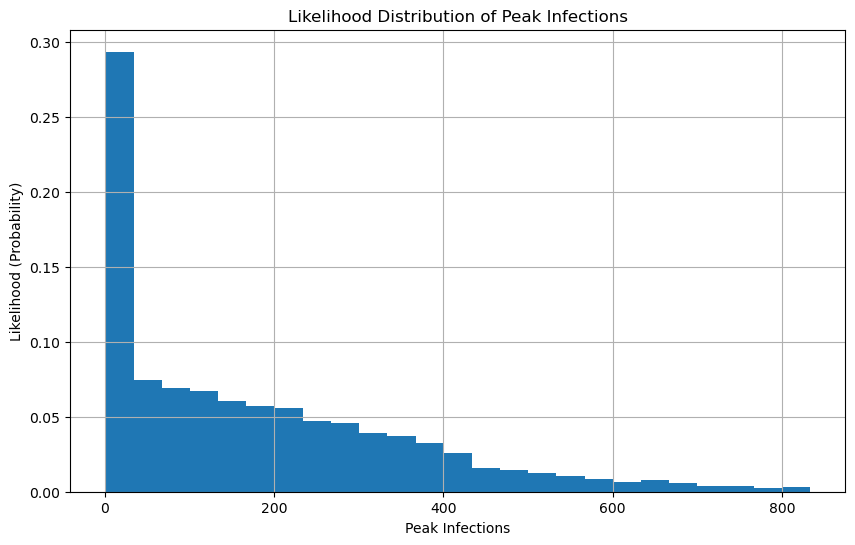

In [6]:
import numpy as np
import matplotlib.pyplot as plt

peak_values = df_results["peak_infections"].values

bins = 25

counts, bin_edges = np.histogram(peak_values, bins=bins)

likelihood = counts / counts.sum()

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2


plt.figure(figsize=(10,6))

plt.bar(
    bin_centers,
    likelihood,
    width=(bin_edges[1] - bin_edges[0]),
)

plt.title("Likelihood Distribution of Peak Infections")
plt.xlabel("Peak Infections")
plt.ylabel("Likelihood (Probability)")
plt.grid()
plt.show()

##### Probability that Peak Infections Stay Below a Given Bed Capacity

Now we move into **true decision analytics.**

You already simulated **10,000 epidemic scenarios**.

Each scenario gives:

* peak_infections
* peak_day

Now planners want to know:

> **What is the probability that healthcare capacity will NOT be breached?**

Meaning:

If hospital bed capacity = **B**

We want:
    
$$
[
P(\text{Peak Infections} \le B)
]
$$

    
This is simply:

> Number of simulations where peak ≤ B
> divided by
> Total number of simulations

This is called:




##### Senior Data Science Insight (Very Important)

What you are now doing is:

> **Monte-Carlo Capacity Risk Estimation**

This is EXACTLY how:

* ICU planning
* Vaccine rollout timing
* Lockdown trigger thresholds
* Supply chain buffering
* Financial stress testing

are evaluated.

You are no longer “running a model”.

You are:

> **Quantifying uncertainty → converting it into actionable probability.**

---




In [7]:
def probability_safe_with_time(df, bed_capacity, prep_days):

    safe = df[
        (df["peak_infections"] <= bed_capacity) &
        (df["peak_day"] >= prep_days)
    ]

    return len(safe) / len(df)

In [9]:
prob = probability_safe_with_time(
    df_results,
    bed_capacity=180,
    prep_days=40
)

print(prob)

0.4827


That is 48.27% of times only 180 beds and 40 days of prep will be enough

IF we conisder only the bedcount variable. 

In [13]:
def probability_safe_bed_count(df, bed_capacity):

    safe = df[
        (df["peak_infections"] <= bed_capacity) 
    ]

    return len(safe) / len(df)

In [14]:
prob = probability_safe_bed_count(
    df_results,
    bed_capacity=180,
)

print(prob)

0.5857


That is 58.27% of times only 180 beds  will be good enough. 

Cumulative Probability that Bed Capacity is Sufficient (Across a Range)

Now we are entering capacity planning analytics, which is a very powerful use of your Monte-Carlo SIR dataset.

You already simulated 10,000 epidemic scenarios with uncertain β and γ.

Now planners want to know:

If we build X beds… what is the probability that beds will be enough?

But not for one value.

For a range of bed capacities like:

100 → 600 beds

We want to compute:

for each capacity level.

This gives a cumulative probability curve.

In [16]:
import numpy as np
import pandas as pd


def cumulative_capacity_probability(df, bed_min, bed_max, step=10):

    capacities = np.arange(bed_min, bed_max + step, step)

    results = []

    total = len(df)

    for beds in capacities:

        safe_cases = (df["peak_infections"] <= beds).sum()

        prob = safe_cases / total

        results.append({
            "bed_capacity": beds,
            "probability_beds_enough": prob
        })

    return pd.DataFrame(results)

In [18]:
capacity_curve = cumulative_capacity_probability(
    df_results,
    bed_min=100,
    bed_max=600,
    step=1
)

capacity_curve.head()

,bed_capacity,probability_beds_enough
0,100,0.4356
1,101,0.4377
2,102,0.4392
3,103,0.4409
4,104,0.4429


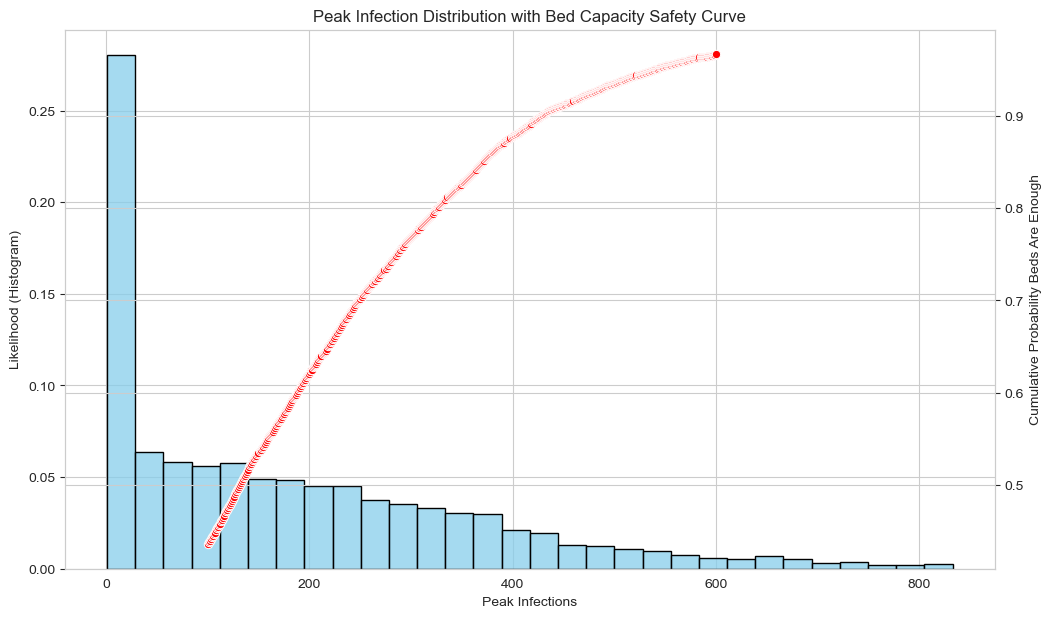

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

fig, ax1 = plt.subplots(figsize=(12,7))


# ---------- Histogram (Peak Infection Distribution)

sns.histplot(
    df_results["peak_infections"],
    bins=30,
    stat="probability",
    color="skyblue",
    edgecolor="black",
    ax=ax1
)

ax1.set_xlabel("Peak Infections")
ax1.set_ylabel("Likelihood (Histogram)")
ax1.set_title("Peak Infection Distribution with Bed Capacity Safety Curve")


# ---------- Second Axis for Cumulative Probability

ax2 = ax1.twinx()

sns.lineplot(
    data=capacity_curve,
    x="bed_capacity",
    y="probability_beds_enough",
    marker="o",
    color="red",
    ax=ax2
)

ax2.set_ylabel("Cumulative Probability Beds Are Enough")


plt.show()

Adding interactvity for bed count.

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

sns.set_style("whitegrid")


def plot_capacity_interactive(bed_capacity):

    fig, ax1 = plt.subplots(figsize=(12,7))

    # Histogram
    sns.histplot(
        df_results["peak_infections"],
        bins=30,
        stat="probability",
        color="skyblue",
        edgecolor="black",
        ax=ax1
    )

    ax1.set_xlabel("Peak Infections")
    ax1.set_ylabel("Likelihood")

    # Vertical Line
    ax1.axvline(
        bed_capacity,
        color="darkblue",
        linestyle="--",
        linewidth=3,
        label=f"Beds = {bed_capacity}"
    )

    # Calculate cumulative probability
    prob = (df_results["peak_infections"] <= bed_capacity).mean()

    ax1.legend(loc="upper left")


    # Second Axis → CDF Curve
    ax2 = ax1.twinx()

    sns.lineplot(
        data=capacity_curve,
        x="bed_capacity",
        y="probability_beds_enough",
        marker="o",
        color="red",
        ax=ax2
    )

    ax2.set_ylabel("Cumulative Probability Beds Are Enough")

    # Highlight current probability point
    ax2.scatter(
        bed_capacity,
        prob,
        color="black",
        s=120,
        zorder=5
    )

    plt.title(
        f"Bed Capacity Safety Analysis | Probability Beds Enough = {prob:.3f}"
    )

    plt.show()



interact(
    plot_capacity_interactive,
    bed_capacity=IntSlider(
        min=int(df_results["peak_infections"].min()),
        max=int(df_results["peak_infections"].max()),
        step=10,
        value=300
    )
);

interactive(children=(IntSlider(value=300, description='bed_capacity', max=833, min=1, step=10), Output()), _d…

Now I want to put a scatter plot of how the peak infection coutn and date on which you are reaching it.

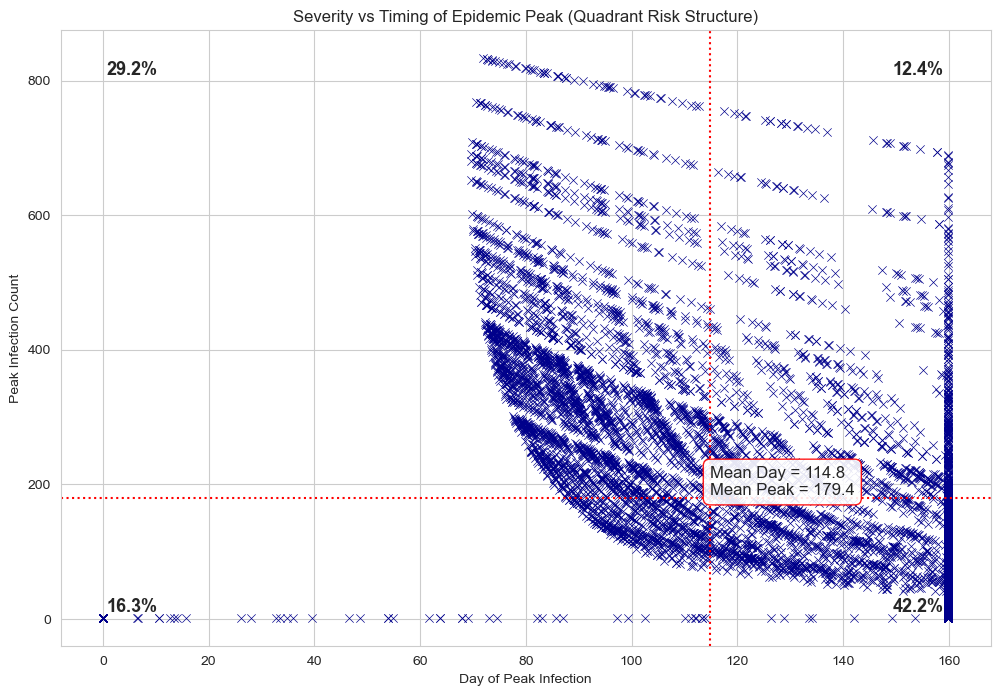

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_style("whitegrid")

x = df_results["peak_day"]
y = df_results["peak_infections"]

mean_x = x.mean()
mean_y = y.mean()

# ---------- Quadrant Percentages ----------

total = len(df_results)

q_tr = ((x >= mean_x) & (y >= mean_y)).sum() / total * 100
q_tl = ((x <  mean_x) & (y >= mean_y)).sum() / total * 100
q_bl = ((x <  mean_x) & (y < mean_y)).sum() / total * 100
q_br = ((x >= mean_x) & (y < mean_y)).sum() / total * 100


# ---------- Plot ----------

plt.figure(figsize=(12,8))

sns.scatterplot(
    x=x,
    y=y,
    marker="x",
    color="darkblue"
)

plt.axvline(mean_x, color="red", linestyle=":")
plt.axhline(mean_y, color="red", linestyle=":")


# ---------- Axis Limits for Corner Placement ----------

xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()

xpad = (xmax - xmin) * 0.05
ypad = (ymax - ymin) * 0.05


# ---------- Quadrant % Labels (Corners)

plt.text(xmax - xpad, ymax - ypad, f"{q_tr:.1f}%", ha="right", va="top", fontsize=13, weight="bold")
plt.text(xmin + xpad, ymax - ypad, f"{q_tl:.1f}%", ha="left", va="top", fontsize=13, weight="bold")
plt.text(xmin + xpad, ymin + ypad, f"{q_bl:.1f}%", ha="left", va="bottom", fontsize=13, weight="bold")
plt.text(xmax - xpad, ymin + ypad, f"{q_br:.1f}%", ha="right", va="bottom", fontsize=13, weight="bold")


# ---------- Mean Value Annotation Box

plt.text(
    mean_x,
    mean_y,
    f"Mean Day = {mean_x:.1f}\nMean Peak = {mean_y:.1f}",
    fontsize=12,
    ha="left",
    va="bottom",
    bbox=dict(
        facecolor="white",
        edgecolor="red",
        boxstyle="round,pad=0.4",
        alpha=0.9
    )
)


plt.xlabel("Day of Peak Infection")
plt.ylabel("Peak Infection Count")

plt.title("Severity vs Timing of Epidemic Peak (Quadrant Risk Structure)")

plt.show()

Most diffiuclt scenario is where you reach peak in less days peak is high. ( Left top quadrant. ). We may try to reduce % there. 

### Full Interactive SIR Monte-Carlo Risk Dashboard

(Simulation → Histogram + CDF → Quadrant Risk Analysis)

Now we will build a single integrated notebook code that:

What this tool will do

You can interactively set:

β distribution

min

max

mean (only informational since uniform mean = midpoint)

γ distribution (triangular)

min

mode (mean-like most likely value)

max

Then when you press a button → simulation runs again:

✅ 10,000 epidemic scenarios generated
✅ Histogram of peak infections (likelihood)
✅ CDF curve of “beds being enough”
✅ Scatter risk-quadrant plot
✅ % of scenarios in each quadrant

In [28]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from ipywidgets import FloatSlider, IntSlider, Button, VBox, HBox, Output

sns.set_style("whitegrid")

output = Output()


# ---------- SIR Solver ----------

def run_sir(beta, gamma, N=1000, I0=1, T=160, dt=0.1):

    steps = int(T/dt)

    S = np.zeros(steps)
    I = np.zeros(steps)
    R = np.zeros(steps)

    S[0] = N - I0
    I[0] = I0

    for t in range(steps-1):

        infection = beta * S[t] * I[t] / N
        recovery = gamma * I[t]

        S[t+1] = S[t] - dt * infection
        I[t+1] = I[t] + dt * (infection - recovery)
        R[t+1] = R[t] + dt * recovery

    peak_I = np.max(I)
    peak_day = np.argmax(I) * dt

    return peak_I, peak_day


# ---------- Dashboard Runner ----------

def run_dashboard(b):

    with output:
        output.clear_output()

        np.random.seed(42)

        beta_samples = np.random.uniform(
            beta_min.value,
            beta_max.value,
            100
        )

        gamma_samples = np.random.triangular(
            gamma_min.value,
            gamma_mode.value,
            gamma_max.value,
            100
        )

        results = []

        for beta in beta_samples:
            for gamma in gamma_samples:

                peak_I, peak_day = run_sir(beta, gamma)

                results.append([beta, gamma, peak_I, peak_day])

        df = pd.DataFrame(
            results,
            columns=["beta","gamma","peak_infections","peak_day"]
        )

        # ---------- Capacity Curve ----------

        capacities = np.arange(50, 600, 10)

        probs = [
            (df["peak_infections"] <= c).mean()
            for c in capacities
        ]

        capacity_curve = pd.DataFrame({
            "bed_capacity": capacities,
            "probability": probs
        })

        # ---------- FIGURE 1 Histogram + CDF ----------

        fig, ax1 = plt.subplots(figsize=(12,7))

        sns.histplot(
            df["peak_infections"],
            bins=30,
            stat="probability",
            color="skyblue",
            edgecolor="black",
            ax=ax1
        )

        ax2 = ax1.twinx()

        sns.lineplot(
            data=capacity_curve,
            x="bed_capacity",
            y="probability",
            color="red",
            marker="o",
            ax=ax2
        )

        ax1.set_title("Peak Infection Distribution + Bed Safety CDF")

        plt.show()


        # ---------- FIGURE 2 Risk Quadrant ----------

        x = df["peak_day"]
        y = df["peak_infections"]

        mean_x = x.mean()
        mean_y = y.mean()

        total = len(df)

        q_tr = ((x>=mean_x)&(y>=mean_y)).sum()/total*100
        q_tl = ((x<mean_x)&(y>=mean_y)).sum()/total*100
        q_bl = ((x<mean_x)&(y<mean_y)).sum()/total*100
        q_br = ((x>=mean_x)&(y<mean_y)).sum()/total*100

        plt.figure(figsize=(12,8))

        sns.scatterplot(x=x,y=y,marker="x",color="darkblue")

        plt.axvline(mean_x,color="red",linestyle=":")
        plt.axhline(mean_y,color="red",linestyle=":")

        xmin,xmax = plt.xlim()
        ymin,ymax = plt.ylim()

        xpad = (xmax-xmin)*0.05
        ypad = (ymax-ymin)*0.05

        plt.text(xmax-xpad,ymax-ypad,f"{q_tr:.1f}%",ha="right",va="top",fontsize=13,weight="bold")
        plt.text(xmin+xpad,ymax-ypad,f"{q_tl:.1f}%",ha="left",va="top",fontsize=13,weight="bold")
        plt.text(xmin+xpad,ymin+ypad,f"{q_bl:.1f}%",ha="left",va="bottom",fontsize=13,weight="bold")
        plt.text(xmax-xpad,ymin+ypad,f"{q_br:.1f}%",ha="right",va="bottom",fontsize=13,weight="bold")

        plt.text(
            mean_x,
            mean_y,
            f"Mean Day={mean_x:.1f}\nMean Peak={mean_y:.1f}",
            bbox=dict(facecolor="white",edgecolor="red")
        )

        plt.title("Risk Quadrant: Severity vs Timing")

        plt.show()


# ---------- Widgets ----------

beta_min = FloatSlider(value=0.05,min=0.01,max=0.5,step=0.01,description="β min")
beta_max = FloatSlider(value=0.15,min=0.02,max=1.0,step=0.01,description="β max")

gamma_min = FloatSlider(value=0.0,min=0.0,max=0.3,step=0.01,description="γ min")
gamma_mode = FloatSlider(value=0.05,min=0.01,max=0.3,step=0.01,description="γ mode")
gamma_max = FloatSlider(value=0.1,min=0.02,max=0.5,step=0.01,description="γ max")

run_button = Button(description="Run Simulation",button_style="success")

run_button.on_click(run_dashboard)


display(
    VBox([
        HBox([beta_min,beta_max]),
        HBox([gamma_min,gamma_mode,gamma_max]),
        run_button,
        output
    ])
)

In above simualtions valaues are taken as random values from the range of the distribution. But below we will take each incremental 1/100the  of that distributio of beta and gamma.

In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from ipywidgets import FloatSlider, Button, VBox, HBox, Output

sns.set_style("whitegrid")

output = Output()


# ---------- SIR Solver ----------

def run_sir(beta, gamma, N=1000, I0=1, T=160, dt=0.1):

    steps = int(T/dt)

    S = np.zeros(steps)
    I = np.zeros(steps)
    R = np.zeros(steps)

    S[0] = N - I0
    I[0] = I0

    for t in range(steps-1):

        infection = beta * S[t] * I[t] / N
        recovery = gamma * I[t]

        S[t+1] = S[t] - dt * infection
        I[t+1] = I[t] + dt * (infection - recovery)
        R[t+1] = R[t] + dt * recovery

    peak_I = np.max(I)
    peak_day = np.argmax(I) * dt

    return peak_I, peak_day


# ---------- Dashboard Runner ----------

def run_dashboard(b):

    with output:
        output.clear_output()

        # GRID sampling (not random)

        beta_values = np.linspace(
            beta_min.value,
            beta_max.value,
            100
        )

        gamma_values = np.linspace(
            gamma_min.value,
            gamma_max.value,
            100
        )

        results = []

        for beta in beta_values:
            for gamma in gamma_values:

                peak_I, peak_day = run_sir(beta, gamma)

                results.append([beta, gamma, peak_I, peak_day])

        df = pd.DataFrame(
            results,
            columns=["beta","gamma","peak_infections","peak_day"]
        )

        # ---------- Capacity CDF ----------

        capacities = np.arange(50,600,10)

        probs = [
            (df["peak_infections"] <= c).mean()
            for c in capacities
        ]

        capacity_curve = pd.DataFrame({
            "bed_capacity": capacities,
            "probability": probs
        })


        # ---------- Plot 1 Histogram + CDF ----------

        fig, ax1 = plt.subplots(figsize=(12,7))

        sns.histplot(
            df["peak_infections"],
            bins=30,
            stat="probability",
            color="skyblue",
            edgecolor="black",
            ax=ax1
        )

        ax2 = ax1.twinx()

        sns.lineplot(
            data=capacity_curve,
            x="bed_capacity",
            y="probability",
            color="red",
            marker="o",
            ax=ax2
        )

        plt.title("Peak Infection Distribution + Bed Safety CDF")

        plt.show()


        # ---------- Plot 2 Risk Quadrant ----------

        x = df["peak_day"]
        y = df["peak_infections"]

        mean_x = x.mean()
        mean_y = y.mean()

        total = len(df)

        q_tr = ((x>=mean_x)&(y>=mean_y)).sum()/total*100
        q_tl = ((x<mean_x)&(y>=mean_y)).sum()/total*100
        q_bl = ((x<mean_x)&(y<mean_y)).sum()/total*100
        q_br = ((x>=mean_x)&(y<mean_y)).sum()/total*100

        plt.figure(figsize=(12,8))

        sns.scatterplot(x=x,y=y,marker="x",color="darkblue")

        plt.axvline(mean_x,color="red",linestyle=":")
        plt.axhline(mean_y,color="red",linestyle=":")

        xmin,xmax = plt.xlim()
        ymin,ymax = plt.ylim()

        xpad = (xmax-xmin)*0.05
        ypad = (ymax-ymin)*0.05

        plt.text(xmax-xpad,ymax-ypad,f"{q_tr:.1f}%",ha="right",va="top",fontsize=13,weight="bold")
        plt.text(xmin+xpad,ymax-ypad,f"{q_tl:.1f}%",ha="left",va="top",fontsize=13,weight="bold")
        plt.text(xmin+xpad,ymin+ypad,f"{q_bl:.1f}%",ha="left",va="bottom",fontsize=13,weight="bold")
        plt.text(xmax-xpad,ymin+ypad,f"{q_br:.1f}%",ha="right",va="bottom",fontsize=13,weight="bold")

        plt.text(
            mean_x,
            mean_y,
            f"Mean Day={mean_x:.1f}\nMean Peak={mean_y:.1f}",
            bbox=dict(facecolor="white",edgecolor="red")
        )

        plt.title("Risk Quadrant: Severity vs Timing")

        plt.show()



# ---------- Widgets ----------

beta_min = FloatSlider(value=0.05,min=0.01,max=0.5,step=0.01,description="β min")
beta_max = FloatSlider(value=0.15,min=0.02,max=1.0,step=0.01,description="β max")

gamma_min = FloatSlider(value=0.01,min=0.0,max=0.3,step=0.01,description="γ min")
gamma_max = FloatSlider(value=0.1,min=0.02,max=0.5,step=0.01,description="γ max")

run_button = Button(description="Run Grid Simulation",button_style="success")

run_button.on_click(run_dashboard)

display(
    VBox([
        HBox([beta_min,beta_max]),
        HBox([gamma_min,gamma_max]),
        run_button,
        output
    ])
)

Combining Everything ( SIR Curves, Histogram and 

In [32]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from ipywidgets import FloatSlider, IntSlider, Button, ToggleButtons, VBox, HBox, Output

sns.set_style("whitegrid")

output = Output()


# ---------- SIR Solver ----------

def run_sir(beta, gamma, T, N=1000, I0=1, dt=0.1):

    steps = int(T/dt)

    S = np.zeros(steps)
    I = np.zeros(steps)
    R = np.zeros(steps)

    S[0] = N - I0
    I[0] = I0

    for t in range(steps-1):

        infection = beta * S[t] * I[t] / N
        recovery = gamma * I[t]

        S[t+1] = S[t] - dt * infection
        I[t+1] = I[t] + dt * (infection - recovery)
        R[t+1] = R[t] + dt * recovery

    peak_I = np.max(I)
    peak_day = np.argmax(I) * dt

    return peak_I, peak_day, S, I, R


# ---------- Dashboard Runner ----------

def run_dashboard(b):

    with output:
        output.clear_output()

        T = days_slider.value

        # ----- Sampling -----

        if sampling_mode.value == "Random":

            beta_values = np.random.uniform(beta_min.value, beta_max.value, 100)

            gamma_values = np.random.triangular(
                gamma_min.value,
                gamma_mode.value,
                gamma_max.value,
                100
            )

        else:

            beta_values = np.linspace(beta_min.value, beta_max.value, 100)
            gamma_values = np.linspace(gamma_min.value, gamma_max.value, 100)

        # ----- Run Simulations -----

        results = []

        for beta in beta_values:
            for gamma in gamma_values:

                peak_I, peak_day, S, I, R = run_sir(beta, gamma, T)

                results.append([beta, gamma, peak_I, peak_day])

        df = pd.DataFrame(
            results,
            columns=["beta","gamma","peak_infections","peak_day"]
        )

        # ---------- Capacity CDF ----------

        capacities = np.arange(50,600,10)

        probs = [(df["peak_infections"] <= c).mean() for c in capacities]

        capacity_curve = pd.DataFrame({
            "bed_capacity": capacities,
            "probability": probs
        })


        # ---------- Plot 1 Histogram + CDF ----------

        fig, ax1 = plt.subplots(figsize=(12,7))

        sns.histplot(
            df["peak_infections"],
            bins=30,
            stat="probability",
            color="skyblue",
            edgecolor="black",
            ax=ax1
        )

        ax2 = ax1.twinx()

        sns.lineplot(
            data=capacity_curve,
            x="bed_capacity",
            y="probability",
            color="red",
            marker="o",
            ax=ax2
        )

        plt.title(f"Peak Infection Distribution + Bed Safety CDF (T={T} days)")
        plt.show()


        # ---------- Plot 2 Risk Quadrant ----------

        x = df["peak_day"]
        y = df["peak_infections"]

        mean_x = x.mean()
        mean_y = y.mean()

        total = len(df)

        q_tr = ((x>=mean_x)&(y>=mean_y)).sum()/total*100
        q_tl = ((x<mean_x)&(y>=mean_y)).sum()/total*100
        q_bl = ((x<mean_x)&(y<mean_y)).sum()/total*100
        q_br = ((x>=mean_x)&(y<mean_y)).sum()/total*100

        plt.figure(figsize=(12,8))

        sns.scatterplot(x=x,y=y,marker="x",color="darkblue")

        plt.axvline(mean_x,color="red",linestyle=":")
        plt.axhline(mean_y,color="red",linestyle=":")

        xmin,xmax = plt.xlim()
        ymin,ymax = plt.ylim()

        xpad = (xmax-xmin)*0.05
        ypad = (ymax-ymin)*0.05

        plt.text(xmax-xpad,ymax-ypad,f"{q_tr:.1f}%",ha="right",va="top",fontsize=13,weight="bold")
        plt.text(xmin+xpad,ymax-ypad,f"{q_tl:.1f}%",ha="left",va="top",fontsize=13,weight="bold")
        plt.text(xmin+xpad,ymin+ypad,f"{q_bl:.1f}%",ha="left",va="bottom",fontsize=13,weight="bold")
        plt.text(xmax-xpad,ymin+ypad,f"{q_br:.1f}%",ha="right",va="bottom",fontsize=13,weight="bold")

        plt.text(
            mean_x,
            mean_y,
            f"Mean Day={mean_x:.1f}\nMean Peak={mean_y:.1f}",
            bbox=dict(facecolor="white",edgecolor="red")
        )

        plt.title("Risk Quadrant: Severity vs Timing")
        plt.show()


        # ---------- Plot 3 Behavioural SIR Curves ----------

        time = np.linspace(0, T, int(T/0.1))

        plt.figure(figsize=(12,7))

        indices = [
            df["peak_infections"].idxmin(),
            df["peak_infections"].idxmax(),
            (df["peak_infections"] - df["peak_infections"].median()).abs().idxmin(),
            df["peak_day"].idxmin(),
            df["peak_day"].idxmax()
        ]

        labels = ["Min Peak","Max Peak","Median Peak","Earliest Peak","Latest Peak"]

        for idx, label in zip(indices, labels):

            beta = df.loc[idx,"beta"]
            gamma = df.loc[idx,"gamma"]

            _, _, S, I, R = run_sir(beta, gamma, T)

            plt.plot(time, I, linewidth=2,
                     label=f"{label} | β={beta:.2f}, γ={gamma:.2f}")

        plt.title("Representative Infection Curves")
        plt.xlabel("Days")
        plt.ylabel("Infected Population")
        plt.legend()
        plt.show()



# ---------- Widgets ----------

sampling_mode = ToggleButtons(options=["Random","Grid"], description="Sampling")

beta_min = FloatSlider(value=0.05,min=0.01,max=0.5,step=0.01,description="β min")
beta_max = FloatSlider(value=0.15,min=0.02,max=1.0,step=0.01,description="β max")

gamma_min = FloatSlider(value=0.0,min=0.0,max=0.3,step=0.01,description="γ min")
gamma_mode = FloatSlider(value=0.05,min=0.01,max=0.3,step=0.01,description="γ mode")
gamma_max = FloatSlider(value=0.1,min=0.02,max=0.5,step=0.01,description="γ max")

days_slider = IntSlider(value=200,min=50,max=800,step=50,description="Days")

run_button = Button(description="Run Simulation",button_style="success")

run_button.on_click(run_dashboard)

display(
    VBox([
        sampling_mode,
        HBox([beta_min,beta_max]),
        HBox([gamma_min,gamma_mode,gamma_max]),
        days_slider,
        run_button,
        output
    ])
)